開始訓練 (Mode: 4, 裝置: cuda)...
--- Epoch [1/15], 目前相位破壞難度 Alpha: 0.00 ---
Epoch [1/15], Loss: 0.2187
--- Epoch [2/15], 目前相位破壞難度 Alpha: 0.10 ---
Epoch [2/15], Loss: 0.0224
--- Epoch [3/15], 目前相位破壞難度 Alpha: 0.20 ---
Epoch [3/15], Loss: 0.0182
--- Epoch [4/15], 目前相位破壞難度 Alpha: 0.30 ---
Epoch [4/15], Loss: 0.0206
--- Epoch [5/15], 目前相位破壞難度 Alpha: 0.40 ---
Epoch [5/15], Loss: 0.0265
--- Epoch [6/15], 目前相位破壞難度 Alpha: 0.50 ---
Epoch [6/15], Loss: 0.0443
--- Epoch [7/15], 目前相位破壞難度 Alpha: 0.60 ---
Epoch [7/15], Loss: 0.0876
--- Epoch [8/15], 目前相位破壞難度 Alpha: 0.70 ---
Epoch [8/15], Loss: 0.1253
--- Epoch [9/15], 目前相位破壞難度 Alpha: 0.80 ---
Epoch [9/15], Loss: 0.1368
--- Epoch [10/15], 目前相位破壞難度 Alpha: 0.90 ---
Epoch [10/15], Loss: 0.1371
--- Epoch [11/15], 目前相位破壞難度 Alpha: 1.00 ---
Epoch [11/15], Loss: 0.1354
--- Epoch [12/15], 目前相位破壞難度 Alpha: 1.00 ---
Epoch [12/15], Loss: 0.1342
--- Epoch [13/15], 目前相位破壞難度 Alpha: 1.00 ---
Epoch [13/15], Loss: 0.1334
--- Epoch [14/15], 目前相位破壞難度 Alpha: 1.00 ---
Epoch [14/

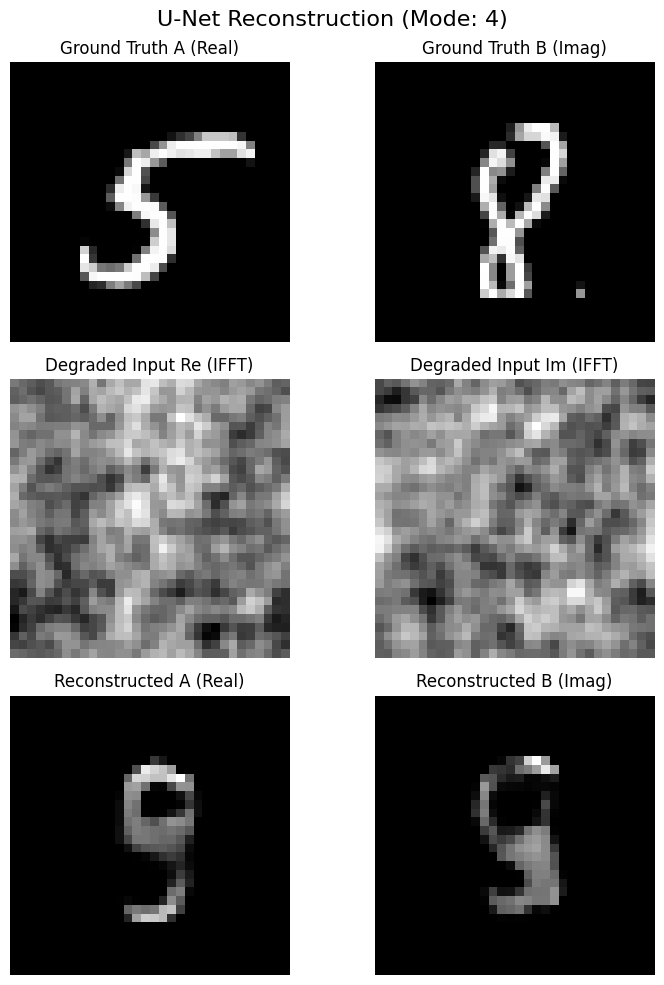

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 參數設定區 (可在此調整 4 種 Mode)
# 1: 原始無破壞
# 2: 加入 50% Beamstop
# 3: 50% Beamstop + 雜訊
# 4: 破壞原始相位
# ==========================================
MODE = 4
HIO_ITERS = 20      # HIO 物理迭代次數
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 資料集建構
class ComplexMNISTDataset(Dataset):
    def __init__(self, train=True):
        # 將 28x28 擴展為 32x32，以符合 U-Net 的連續 2x2 Pooling
        transform = transforms.Compose([
            transforms.Pad(2),
            transforms.ToTensor()
        ])
        self.mnist = datasets.MNIST(root='./data', train=train, download=True, transform=transform)
        self.length = len(self.mnist)
        # 產生一個隨機索引陣列來配對圖片 B
        self.shift_idx = torch.randperm(self.length)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img_a, _ = self.mnist[idx]
        img_b, _ = self.mnist[self.shift_idx[idx]]
        # 結合成 2-channel Tensor: [實部, 虛部]
        complex_target = torch.cat([img_a, img_b], dim=0)
        return complex_target

def hio_phase_retrieval(magnitude, max_iters=20, beta=0.9):
    B, H, W = magnitude.shape

    # 初始化：給予完全隨機的相位作為起點
    random_phase = (torch.rand_like(magnitude) * 2 * torch.pi) - torch.pi
    complex_guess = torch.polar(magnitude, random_phase)
    x_k = torch.fft.ifft2(torch.fft.ifftshift(complex_guess, dim=(-2, -1)), norm="ortho")

    for _ in range(max_iters):
        # A. 前向 FFT
        X_k = torch.fft.fftshift(torch.fft.fft2(x_k, norm="ortho"), dim=(-2, -1))
        # B. 頻域約束 (套用真實振幅)
        X_k_prime = torch.polar(magnitude, X_k.angle())
        # C. 反向 IFFT
        x_k_prime = torch.fft.ifft2(torch.fft.ifftshift(X_k_prime, dim=(-2, -1)), norm="ortho")

        # D. 空間域約束 (MNIST 像素值必須 >= 0)
        re_pass = x_k_prime.real >= 0
        im_pass = x_k_prime.imag >= 0

        new_re = torch.where(re_pass, x_k_prime.real, x_k.real - beta * x_k_prime.real)
        new_im = torch.where(im_pass, x_k_prime.imag, x_k.imag - beta * x_k_prime.imag)
        x_k = torch.complex(new_re, new_im)

    return x_k

# 2. 物理退化層 (傅立葉域處理)
def apply_physics_degradation(target_tensor, mode, alpha=1.0):
    # target_tensor: [B, 2, H, W]
    B, C, H, W = target_tensor.shape
    # 將 Channel 0, 1 轉為真正的複數張量
    complex_x = torch.complex(target_tensor[:, 0, :, :], target_tensor[:, 1, :, :])

    # 進行 2D 傅立葉轉換並將低頻移至中心
    fft_x = torch.fft.fftshift(torch.fft.fft2(complex_x), dim=(-2, -1))

    if mode == 1:
        # Option 1: 無破壞
        corrupted_fft = fft_x

    elif mode == 2:
        # Option 2: 50% Beamstop (遮蔽中心低頻區)
        corrupted_fft = fft_x.clone()
        mask_size = int(H * 0.5)
        c_h, c_w = H // 2, W // 2
        corrupted_fft[:, c_h - mask_size//2 : c_h + mask_size//2,
                         c_w - mask_size//2 : c_w + mask_size//2] = 0

    elif mode == 3:
        corrupted_fft = fft_x.clone()
        mask_size = int(H * 0.5)
        c_h, c_w = H // 2, W // 2
        corrupted_fft[:, c_h - mask_size//2 : c_h + mask_size//2,
                         c_w - mask_size//2 : c_w + mask_size//2] = 0

        # 依據目前頻譜的最大振幅，給予 5% 的相對雜訊
        max_amp = torch.max(torch.abs(corrupted_fft)).item()
        noise_scale = max_amp * 0.05

        noise_real = torch.randn_like(corrupted_fft.real) * noise_scale
        noise_imag = torch.randn_like(corrupted_fft.imag) * noise_scale
        corrupted_fft = corrupted_fft + torch.complex(noise_real, noise_imag)

    elif mode == 4:

        magnitude = torch.abs(fft_x)
        true_phase = torch.angle(fft_x)

        # 產生完全隨機的相位
        random_phase = (torch.rand_like(magnitude) * 2 * torch.pi) - torch.pi

        # 將真實相位與隨機相位進行混合
        # alpha 越小，保留越多真實相位；alpha 為 1 時，完全是隨機相位
        blended_phase = (1.0 - alpha) * true_phase + alpha * random_phase

        # 結合成新的複數並 IFFT 轉回空間域
        corrupted_fft = torch.polar(magnitude, blended_phase)
        ifft_x = torch.fft.ifft2(torch.fft.ifftshift(corrupted_fft, dim=(-2, -1)), norm="ortho")

        return torch.stack([ifft_x.real, ifft_x.imag], dim=1)

    # 反傅立葉轉換回空間域
    ifft_x = torch.fft.ifft2(torch.fft.ifftshift(corrupted_fft, dim=(-2, -1)))

    # 將複數拆解回 2-channel 實數張量作為 U-Net 輸入
    return torch.stack([ifft_x.real, ifft_x.imag], dim=1)

# 3. U-Net 模型定義
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 2 channels (受損的 Re, Im), Output: 2 channels (重建的 Re, Im)
        self.inc = DoubleConv(2, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128)) # 瓶頸層

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64) # 64 (up) + 64 (skip) = 128

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(64, 32)  # 32 (up) + 32 (skip) = 64

        self.outc = nn.Conv2d(32, 2, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        # 擴張路徑與跳躍連接
        x = self.up1(x3)
        x = self.conv1(torch.cat([x, x2], dim=1))
        x = self.up2(x)
        x = self.conv2(torch.cat([x, x1], dim=1))

        # 最終輸出使用 Sigmoid 將數值壓縮回 0~1 (原圖的像素範圍)
        logits = self.outc(x)
        return torch.sigmoid(logits)

def total_variation_loss(img):
    # img shape: [B, C, H, W]
    # 計算垂直方向的像素差異
    tv_h = torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]).mean()
    # 計算水平方向的像素差異
    tv_w = torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]).mean()
    return tv_h + tv_w

# 4. 訓練流程與視覺化
def train_and_visualize():
    # 準備資料
    train_dataset = ComplexMNISTDataset(train=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model = UNet().to(DEVICE)
    criterion_l1 = nn.L1Loss()
    criterion_mse = nn.MSELoss()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=2e-3,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader)
    )

    print(f"開始訓練 (Mode: {MODE}, 裝置: {DEVICE})...")

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        current_alpha = min(1.0, epoch / 10.0)
        print(f"--- Epoch [{epoch+1}/{EPOCHS}], 目前相位破壞難度 Alpha: {current_alpha:.2f} ---")

        for batch_idx, targets in enumerate(train_loader):
            targets = targets.to(DEVICE)

            # 動態生成退化後的輸入
            inputs = apply_physics_degradation(targets, mode=MODE, alpha=current_alpha).float().to(DEVICE)
            # 因為退化後的數據範圍可能很大，神經網路由 BatchNorm 處理適應，但需確保型別
            inputs = inputs.float().to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss_l1 = criterion_l1(outputs, targets)
            loss_mse = criterion_mse(outputs, targets)

            # 1. 攤平 Output 與 Target
            out_a_flat = outputs[:, 0].view(outputs.size(0), -1)
            out_b_flat = outputs[:, 1].view(outputs.size(0), -1)
            target_a_flat = targets[:, 0].view(targets.size(0), -1)
            target_b_flat = targets[:, 1].view(targets.size(0), -1)

            # 2. 分別計算 Output 的相似度 與 Target 的真實相似度
            out_sim = torch.nn.functional.cosine_similarity(out_a_flat, out_b_flat, dim=1)
            target_sim = torch.nn.functional.cosine_similarity(target_a_flat, target_b_flat, dim=1)

            # 3. 新的懲罰：要求兩者的相似度必須一致 (計算 MSE)
            sim_penalty = torch.nn.functional.mse_loss(out_sim, target_sim)

            # 4. 頻域振幅損失 (Spectral Magnitude Loss)
            # 將輸出的 A, B 組合成複數，並轉到頻域
            out_complex = torch.complex(outputs[:, 0], outputs[:, 1])
            target_complex = torch.complex(targets[:, 0], targets[:, 1])

            out_fft = torch.fft.fft2(out_complex, norm='ortho')
            target_fft = torch.fft.fft2(target_complex, norm='ortho')

            loss_fft = criterion_l1(torch.abs(out_fft), torch.abs(target_fft))

            # 加入 TV Loss (計算輸出的平滑度)
            loss_tv = total_variation_loss(outputs)

            # 重新組合總 Loss：
            loss = loss_l1 + 0.5 * loss_mse + 0.05 * sim_penalty + 0.1 * loss_fft + 0.1 * loss_tv

            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

    # 視覺化對照結果
    model.eval()
    with torch.no_grad():
        sample_targets = next(iter(train_loader)).to(DEVICE)
        sample_inputs = apply_physics_degradation(sample_targets, mode=MODE).float().to(DEVICE)
        sample_outputs = model(sample_inputs)

        # 取 Batch 中的第一筆資料畫圖
        target_re, target_im = sample_targets[0, 0].cpu(), sample_targets[0, 1].cpu()
        input_re, input_im = sample_inputs[0, 0].cpu(), sample_inputs[0, 1].cpu()
        output_re, output_im = sample_outputs[0, 0].cpu(), sample_outputs[0, 1].cpu()

        fig, axes = plt.subplots(3, 2, figsize=(8, 10))
        fig.suptitle(f'U-Net Reconstruction (Mode: {MODE})', fontsize=16)

        axes[0, 0].imshow(target_re, cmap='gray')
        axes[0, 0].set_title("Ground Truth A (Real)")
        axes[0, 1].imshow(target_im, cmap='gray')
        axes[0, 1].set_title("Ground Truth B (Imag)")

        axes[1, 0].imshow(input_re, cmap='gray')
        axes[1, 0].set_title("Degraded Input Re (IFFT)")
        axes[1, 1].imshow(input_im, cmap='gray')
        axes[1, 1].set_title("Degraded Input Im (IFFT)")

        axes[2, 0].imshow(output_re, cmap='gray')
        axes[2, 0].set_title("Reconstructed A (Real)")
        axes[2, 1].imshow(output_im, cmap='gray')
        axes[2, 1].set_title("Reconstructed B (Imag)")

        for ax in axes.flatten():
            ax.axis('off')

        plt.tight_layout()
        plt.show()

if __name__ == '__main__':
    train_and_visualize()